In [2]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Carica il dataset
df = pd.read_csv('C:\\Users\\HP\\Desktop\\data_science\\primo_anno\\DSLab\\DS_Lab\\cleaned_df2.csv')

target = 'cyber_fraud_victim'
results = []

# Separiamo le variabili dal target
features = [col for col in df.columns if col != target and col != 'wght'] # Escludiamo i pesi

for col in features:
    # Rimuoviamo i NaN per il calcolo univariato
    temp_df = df[[col, target]].dropna()
    if temp_df.empty or len(temp_df[col].unique()) <= 1:
        continue
        
    col_type = temp_df[col].dtype
    p_value = np.nan
    test_used = ""
    
    # --- Test per Continue/Ordinali ---
    if pd.api.types.is_numeric_dtype(col_type):
        group0 = temp_df[temp_df[target] == 0][col]
        group1 = temp_df[temp_df[target] == 1][col]
        
        if len(group0) > 0 and len(group1) > 0:
            stat, p_value = mannwhitneyu(group0, group1, alternative='two-sided')
            test_used = "Mann-Whitney U"
            
    # --- Test per Categoriche ---
    else:
        contingency_table = pd.crosstab(temp_df[col], temp_df[target])
        # Eseguiamo il Chi-Quadro solo se la tabella ha senso
        if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
            stat, p_value, dof, expected = chi2_contingency(contingency_table)
            test_used = "Chi-Square"
            
    # --- Mutual Information (Richiede codifica numerica per le categoriche) ---
    if pd.api.types.is_numeric_dtype(col_type):
        mi_score = mutual_info_classif(temp_df[[col]], temp_df[target], random_state=42)[0]
    else:
        le = LabelEncoder()
        encoded_col = le.fit_transform(temp_df[col])
        mi_score = mutual_info_classif(encoded_col.reshape(-1, 1), temp_df[target], random_state=42)[0]
        
    results.append({
        'Feature': col,
        'Test_Used': test_used,
        'P_Value': p_value,
        'Significant (p<0.05)': p_value < 0.05,
        'Mutual_Information': mi_score
    })

# Creiamo il report finale
evaluation_df = pd.DataFrame(results)
# Ordiniamo per Mutual Information decrescente e P-value crescente
evaluation_df = evaluation_df.sort_values(by=['Mutual_Information', 'P_Value'], ascending=[False, True])

print(evaluation_df.head(20))

                                Feature       Test_Used        P_Value  \
25               institutional_friction  Mann-Whitney U  3.438624e-184   
26                      credit_excluded  Mann-Whitney U  1.614385e-147   
24           advanced_fintech_intensity  Mann-Whitney U   1.409699e-73   
21             digital_onboarding_score  Mann-Whitney U   5.672320e-63   
23        daily_transactional_intensity  Mann-Whitney U   1.623263e-36   
49                         income_label      Chi-Square   3.178653e-35   
8           saving_level_sophistication  Mann-Whitney U   2.112637e-32   
3            expenditure_shock_capacity      Chi-Square   6.583663e-37   
31                            qk6_clean  Mann-Whitney U   1.925746e-39   
10                private_pension_asset  Mann-Whitney U   2.592537e-20   
44                       household_size  Mann-Whitney U   1.982110e-11   
4            retirement_plan_confidence      Chi-Square   8.568116e-08   
35                 subj_knowledge_labe

In [ ]:
evaluation_df[evaluation_df['Significant (p<0.05)'] == False]

,Feature,Test_Used,P_Value,Significant (p<0.05),Mutual_Information
17,consumer_debt_score,Mann-Whitney U,0.068941,False,0.005333
1,personal_budget_decisions,Chi-Square,0.078932,False,0.004825
38,behaviour_investement-payment,Mann-Whitney U,0.446701,False,0.004784
48,is_italian,Chi-Square,0.875164,False,0.003778
47,work_status,Chi-Square,0.215486,False,0.003680
41,macro_region_label,Chi-Square,0.531126,False,0.003658
36,gap_class,Chi-Square,0.965503,False,0.003154
9,state_employee_pension,Mann-Whitney U,0.972770,False,0.002363
15,transactional_score,Mann-Whitney U,0.400643,False,0.000397
30,qk5_clean,Mann-Whitney U,0.063741,False,0.000000


: 

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# 2. LISTA NERA: Target, pesi e variabili NON significative
vars_to_exclude = [
    target, 
    'wght', # Rimuoviamo il peso campionario
    'consumer_debt_score', 
    'personal_budget_decisions', 
    'behaviour_investement-payment', 
    'is_italian', 
    'work_status', 
    'macro_region_label', 
    'gap_class', 
    'state_employee_pension', 
    'transactional_score', 
    'qk5_clean', 
    'internet_access_label', 
    'urban_area_label', 
    'traditional_investment_score', 
    'qk4_clean'
]

# 3. LISTA BIANCA: Selezione dinamica delle variabili significative
significant_features = [col for col in df.columns if col not in vars_to_exclude]
print(f"Variabili significative mantenute: {len(significant_features)}\n")

# 4. Preparazione Dati (Encoding e pulizia)
X_sig = df[significant_features].copy()
# Trasforma le categoriche in 0/1 (es. gender_Woman, age_group_50-59)
X_numeric = pd.get_dummies(X_sig, drop_first=True).astype(float)
# Imputiamo eventuali NaN rimasti con la mediana per non far rompere i modelli
X_numeric = X_numeric.fillna(X_numeric.median())

# ==========================================
# PARTE A: TEST DI COLLINEARITÀ (VIF)
# ==========================================
print("Calcolo del VIF in corso...\n")
vif_data = pd.DataFrame()
vif_data["Feature"] = X_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric.values, i) for i in range(X_numeric.shape[1])]

high_vif = vif_data[vif_data["VIF"] > 5].sort_values(by="VIF", ascending=False)
if not high_vif.empty:
    print("⚠️ ATTENZIONE: Le seguenti variabili hanno forte collinearità (VIF > 5).")
    print("Considera di aggiungerne alcune alla lista 'vars_to_exclude' se i modelli performano in modo strano:")
    print(high_vif.head(10).to_string(index=False))
else:
    print("✅ Ottimo! Nessuna variabile ha un VIF critico.")

print("\n" + "="*40 + "\n")

Variabili significative mantenute: 37

Calcolo del VIF in corso...

⚠️ ATTENZIONE: Le seguenti variabili hanno forte collinearità (VIF > 5).
Considera di aggiungerne alcune alla lista 'vars_to_exclude' se i modelli performano in modo strano:
                         Feature         VIF
                       qk1_clean 1405.758435
        subj_knowledge_label_Low  414.044443
subj_knowledge_label_Not defined  167.344229
     subj_knowledge_label_Medium  111.534540
   income_not_covering_costs_yes   11.208874
               use_own_resources   10.707459
                 age_group_50-59   10.474189
                 age_group_60-69    9.866781
                 age_group_40-49    9.843133
                 age_group_30-39    9.394416




In [4]:
# 2. LISTA NERA: Target, pesi, variabili NON significative e variabili COLLINEARI
vars_to_excludee = [
    target, 
    'wght', 
    'consumer_debt_score', 
    'personal_budget_decisions', 
    'behaviour_investement-payment', 
    'is_italian', 
    'work_status', 
    'macro_region_label', 
    'gap_class', 
    'state_employee_pension', 
    'transactional_score', 
    'qk5_clean', 
    'internet_access_label', 
    'urban_area_label', 
    'traditional_investment_score', 
    'qk4_clean',
    # --- NUOVE AGGIUNTE DAL TEST VIF ---
    'subj_knowledge_label', # Clone categorico di qk1_clean
    'use_own_resources',    # Sovrapposta a income_not_covering_costs
    'age_group'             # Crea rumore ed è assorbita dai digital scores
]

Significant variables retained: 34

--- RANDOM FOREST PERFORMANCE (Target 1 = Fraud) ---
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       881
           1       0.53      0.48      0.50        92

    accuracy                           0.91       973
   macro avg       0.74      0.72      0.73       973
weighted avg       0.91      0.91      0.91       973



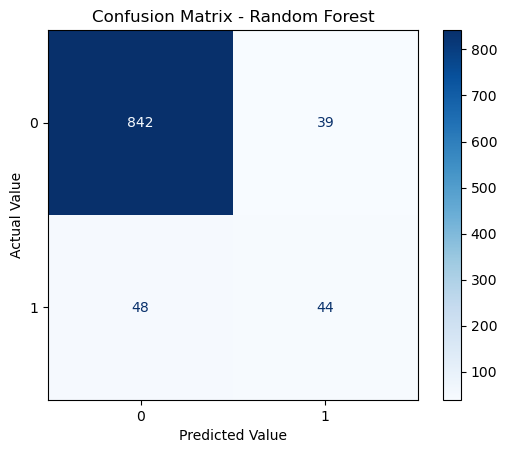

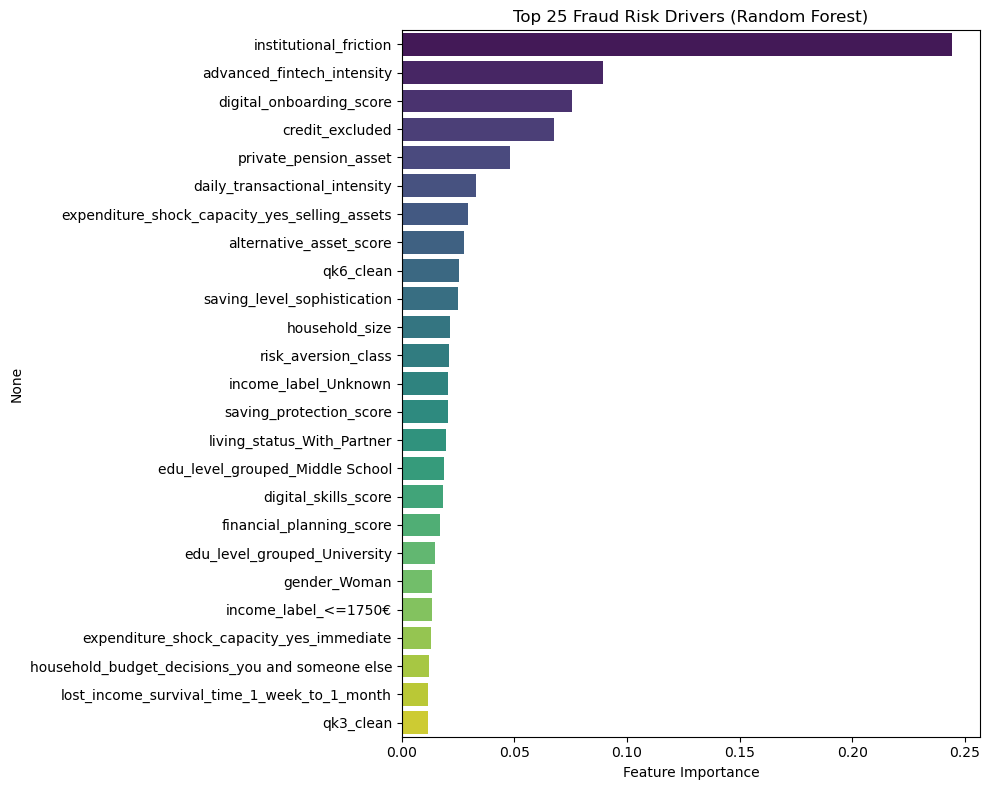

In [5]:
# ==========================================
# PART B: MODEL TRAINING
# ==========================================

significant_features = [
    col for col in df.columns
    if col not in vars_to_excludee
]

print(
    f"Significant variables retained: "
    f"{len(significant_features)}\n"
)

# 4. Data Preparation (Encoding and Cleaning)
X_sig = df[significant_features].copy()

# Convert categorical variables into 0/1 dummies
# (e.g. gender_Woman, age_group_50-59)
X_numeric = pd.get_dummies(
    X_sig,
    drop_first=True
).astype(float)

# Impute any remaining NaN values with the median
# to prevent model failures
X_numeric = X_numeric.fillna(
    X_numeric.median()
)

# Target Variable
# Remove any NaN values for safety
y = df[target].fillna(0)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Oversampling with SMOTE
# (training set only!)
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# --- Model 1: Classification Tree ---
# Maximum depth = 4 to keep it slide-friendly
dt_model = DecisionTreeClassifier(
    max_depth=4,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(
    X_train_smote,
    y_train_smote
)

# --- Model 2: Random Forest ---
# High-performance predictive engine
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

# Model Evaluation
y_pred_rf = rf_model.predict(X_test)

print(
    "--- RANDOM FOREST PERFORMANCE "
    "(Target 1 = Fraud) ---"
)

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")

plt.show()

# ==========================================
# PART C: INSIGHT EXTRACTION FOR THE PITCH
# ==========================================

plt.figure(figsize=(10, 8))

# Extract the 25 most important features
# identified by the Random Forest
feature_imp = pd.Series(
    rf_model.feature_importances_,
    index=X_numeric.columns
).sort_values(
    ascending=False
).head(25)

sns.barplot(
    x=feature_imp,
    y=feature_imp.index,
    palette="viridis",
    hue=feature_imp.index,
    legend=False
)

plt.title(
    "Top 25 Fraud Risk Drivers "
    "(Random Forest)"
)

plt.xlabel(
    "Feature Importance"
)

plt.tight_layout()
plt.show()

In [6]:
# Estraiamo le top 12 variabili più importanti dal modello Random Forest
top_vars = pd.Series(rf_model.feature_importances_, index=X_numeric.columns).sort_values(ascending=False)

print("--- LE 'TITOLARI' PER IL PITCH AZIENDALE ---")
print(top_vars.head(18).to_string(float_format=lambda x: "{:.4f}".format(x)))

--- LE 'TITOLARI' PER IL PITCH AZIENDALE ---
institutional_friction                          0.2444
advanced_fintech_intensity                      0.0892
digital_onboarding_score                        0.0757
credit_excluded                                 0.0677
private_pension_asset                           0.0479
daily_transactional_intensity                   0.0327
expenditure_shock_capacity_yes_selling_assets   0.0292
alternative_asset_score                         0.0275
qk6_clean                                       0.0255
saving_level_sophistication                     0.0248
household_size                                  0.0214
risk_aversion_class                             0.0211
income_label_Unknown                            0.0207
saving_protection_score                         0.0204
living_status_With_Partner                      0.0196
edu_level_grouped_Middle School                 0.0186
digital_skills_score                            0.0183
financial_planning_s

In [ ]:
pip install shap scikit-plot statsmodels

--- TOP 18 SELECTED VARIABLES (Academic Pipeline) ---
['institutional_friction', 'advanced_fintech_intensity', 'digital_onboarding_score', 'credit_excluded', 'private_pension_asset', 'daily_transactional_intensity', 'expenditure_shock_capacity_yes_selling_assets', 'alternative_asset_score', 'qk6_clean', 'saving_level_sophistication', 'household_size', 'risk_aversion_class', 'income_label_Unknown', 'saving_protection_score', 'living_status_With_Partner', 'edu_level_grouped_Middle School', 'digital_skills_score', 'financial_planning_score']

--- STATISTICAL INFERENCE: ODDS RATIO AND P-VALUE ---
Rule: Consider ONLY variables with Significant = True.
                                      Feature  Coefficient  Odds_Ratio  P_Value  Significant (p<0.05)
                       institutional_friction       1.7193      5.5808   0.0000                  True
                              credit_excluded       1.6963      5.4537   0.0000                  True
expenditure_shock_capacity_yes_selling_

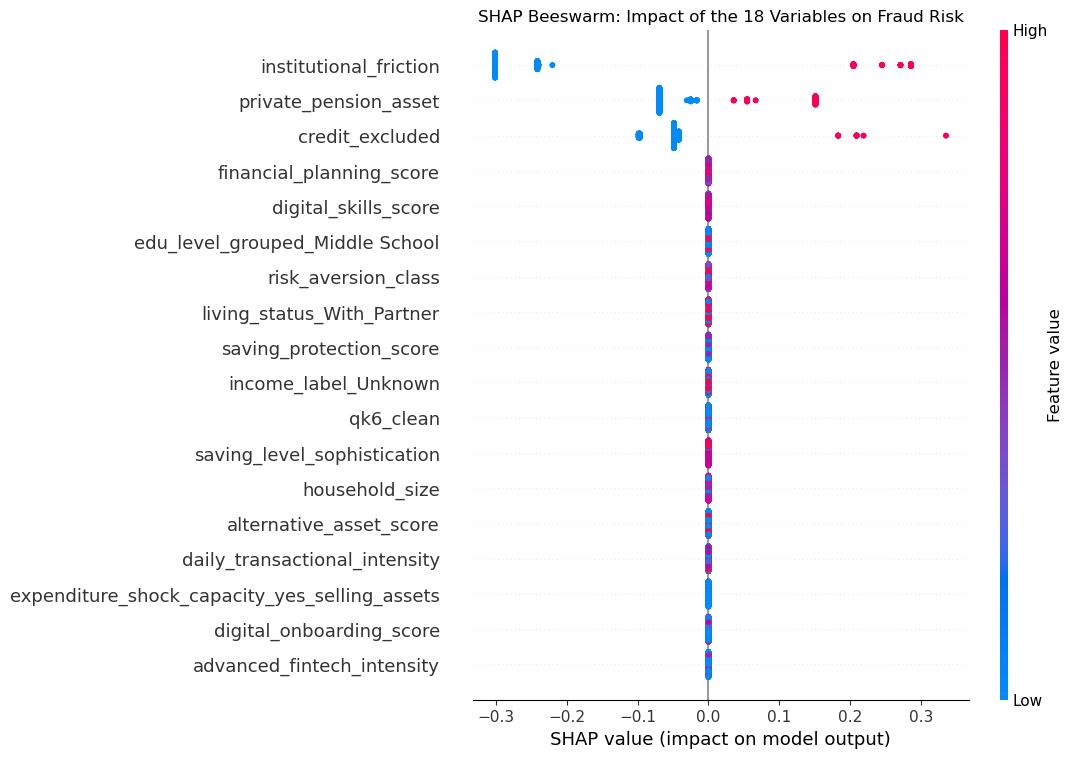

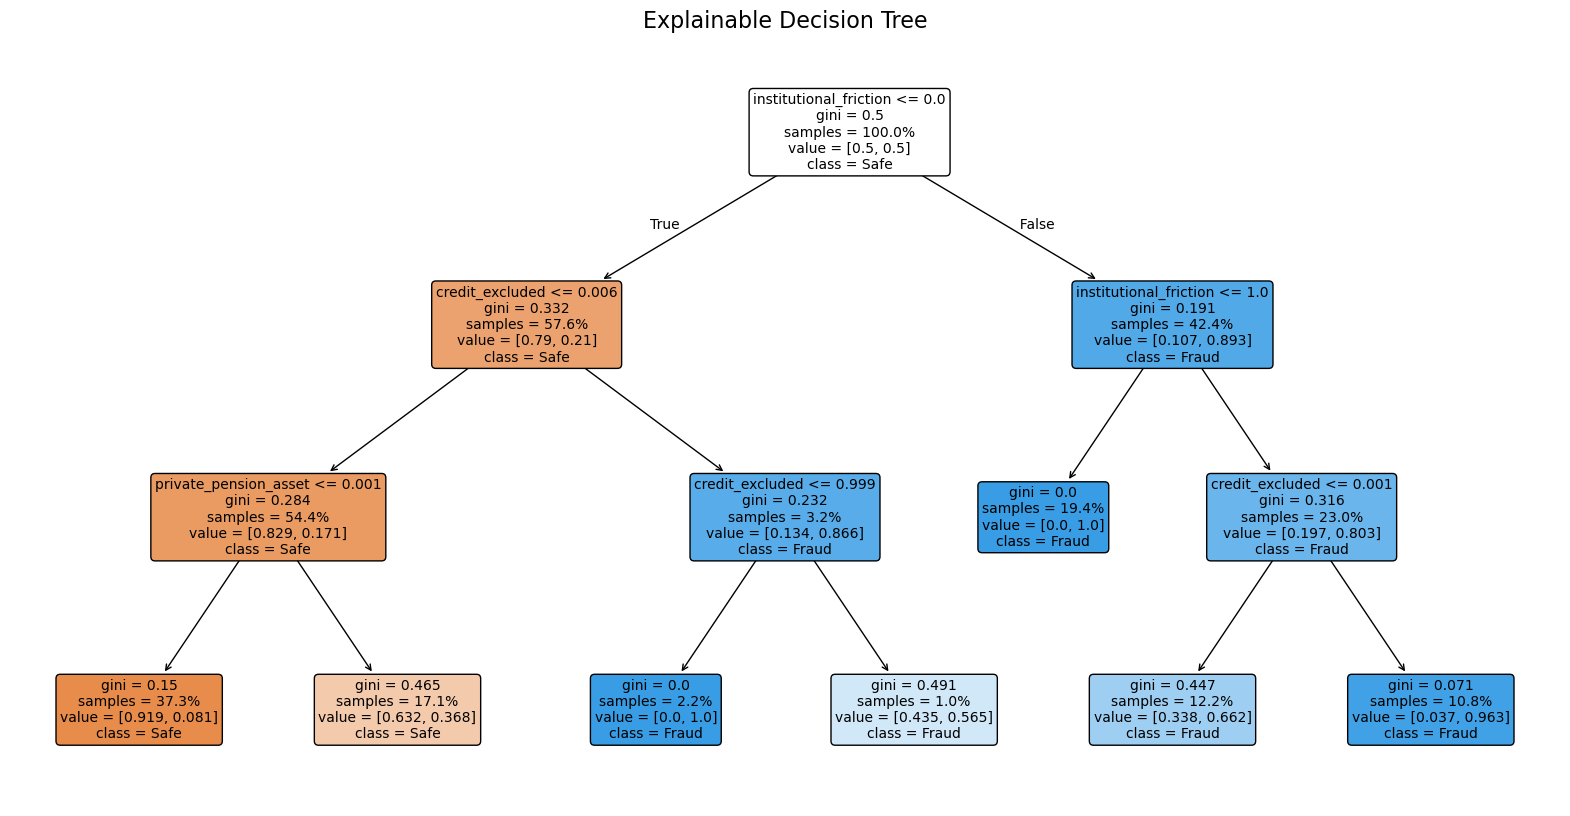

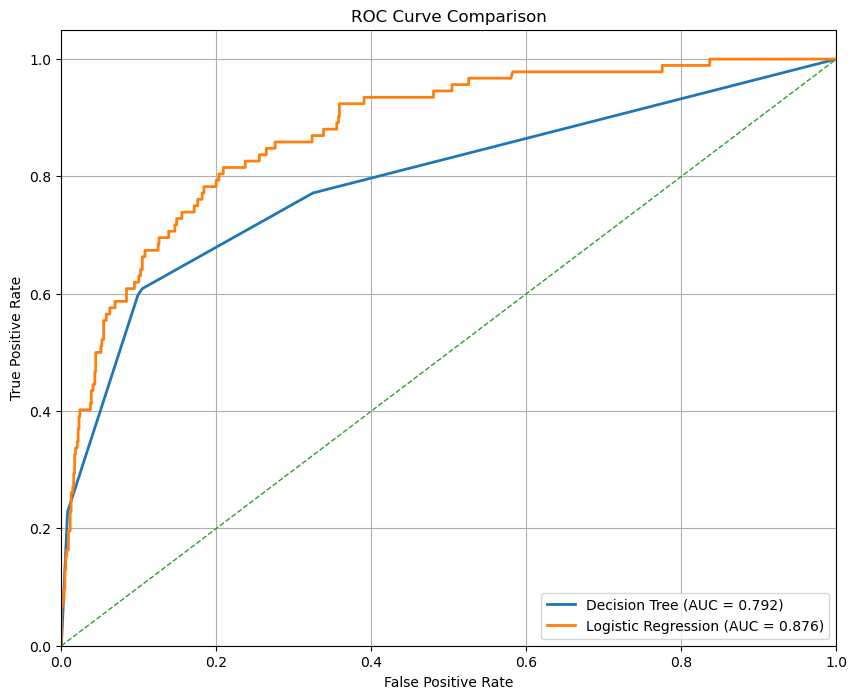

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import shap
import scipy

scipy.interp = np.interp

import scikitplot as skplt
from sklearn.metrics import roc_curve, auc
import statsmodels.api as sm

X_train, X_test, y_train, y_test = train_test_split(
    X_numeric,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. SMOTE
# (Training set only to avoid data leakage)
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# =========================================================
# PHASE 1: FEATURE SELECTION
# (On the balanced training set)
# =========================================================

rf_selector = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42
)

rf_selector.fit(
    X_train_smote,
    y_train_smote
)

# Extract top 18 empirical features
feature_importances = pd.Series(
    rf_selector.feature_importances_,
    index=X_train_smote.columns
)

top_18_features = (
    feature_importances
    .sort_values(ascending=False)
    .head(18)
    .index
    .tolist()
)

print(
    "--- TOP 18 SELECTED VARIABLES "
    "(Academic Pipeline) ---"
)

print(top_18_features)

# =========================================================
# PHASE 2: SUBSETTING AND RETRAINING
# ON THE TOP 18
# =========================================================

# Reduce dimensional spaces
# to selected variables only
X_train_smote_18 = X_train_smote[top_18_features]
X_train_18 = X_train[top_18_features]
X_test_18 = X_test[top_18_features]

# ---------------------------------------------------------
# MODEL A: LOGISTIC REGRESSION
# (Sklearn for probabilities,
# Statsmodels for inference)
# ---------------------------------------------------------

# Sklearn model
# (ROC + predictions)
log_reg = LogisticRegression(
    max_iter=2000,
    random_state=42,
    class_weight='balanced'
)

log_reg.fit(
    X_train_18,
    y_train
)

# Statsmodels model
# (statistical significance extraction)
X_train_sm = sm.add_constant(X_train_18)

try:
    logit_model = sm.Logit(
        y_train,
        X_train_sm
    )

    result = logit_model.fit(
        disp=False
    )

    infer_df = pd.DataFrame({
        'Feature': result.params.index,
        'Coefficient': result.params.values,
        'Odds_Ratio': np.exp(result.params.values),
        'P_Value': result.pvalues.values
    })

    # Remove intercept
    infer_df = infer_df[
        infer_df['Feature'] != 'const'
    ]

    infer_df[
        'Significant (p<0.05)'
    ] = infer_df['P_Value'] < 0.05

    infer_df = infer_df.sort_values(
        by='Odds_Ratio',
        ascending=False
    )

    print(
        "\n--- STATISTICAL INFERENCE: "
        "ODDS RATIO AND P-VALUE ---"
    )

    print(
        "Rule: Consider ONLY variables "
        "with Significant = True."
    )

    print(
        infer_df.to_string(
            index=False,
            float_format=lambda x: "{:.4f}".format(x)
        )
    )

except Exception as e:

    print(
        f"\nUnable to compute p-values "
        f"with Statsmodels due to: {e}"
    )

    # Fallback
    odds_ratios = np.exp(
        log_reg.coef_[0]
    )

    odds_df = pd.DataFrame({
        'Feature': top_18_features,
        'Odds Ratio': odds_ratios
    }).sort_values(
        by='Odds Ratio',
        ascending=False
    )

    print(odds_df)

# ---------------------------------------------------------
# MODEL B: DECISION TREE
# (Business slide explainability)
# ---------------------------------------------------------

dt_model = DecisionTreeClassifier(
    max_depth=3,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(
    X_train_smote_18,
    y_train_smote
)

# =========================================================
# PHASE 3: EVALUATION
# (On untouched original test set)
# + Explainable AI
# =========================================================

y_pred_dt = dt_model.predict(
    X_test_18
)

print(
    "\n--- CONFUSION MATRIX "
    "(Real Test Set) ---"
)

print(
    confusion_matrix(
        y_test,
        y_pred_dt
    )
)

print(
    "\n--- CLASSIFICATION REPORT ---"
)

print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

# SHAP Beeswarm Plot
print("\nGenerating SHAP values...")

explainer = shap.TreeExplainer(
    dt_model
)

shap_values = explainer(
    X_test_18
)

plt.figure()

plt.title(
    "SHAP Beeswarm: Impact of the "
    "18 Variables on Fraud Risk"
)

try:
    shap.plots.beeswarm(
        shap_values[:, :, 1],
        max_display=18
    )
except:
    shap.plots.beeswarm(
        shap_values,
        max_display=18
    )

# Decision Tree Visualization
plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=top_18_features,
    class_names=['Safe', 'Fraud'],
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=10
)

plt.title(
    "Explainable Decision Tree",
    fontsize=16
)

plt.show()

# ============================
# ROC CURVE COMPARISON
# ============================

y_pred_dt_proba = dt_model.predict_proba(
    X_test_18
)[:, 1]

y_pred_log_proba = log_reg.predict_proba(
    X_test_18
)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(
    y_test,
    y_pred_dt_proba
)

roc_auc_dt = auc(
    fpr_dt,
    tpr_dt
)

fpr_log, tpr_log, _ = roc_curve(
    y_test,
    y_pred_log_proba
)

roc_auc_log = auc(
    fpr_log,
    tpr_log
)

plt.figure(figsize=(10, 8))

plt.plot(
    fpr_dt,
    tpr_dt,
    linewidth=2,
    label=f'Decision Tree (AUC = {roc_auc_dt:.3f})'
)

plt.plot(
    fpr_log,
    tpr_log,
    linewidth=2,
    label=f'Logistic Regression (AUC = {roc_auc_log:.3f})'
)

# Random baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel(
    'False Positive Rate'
)

plt.ylabel(
    'True Positive Rate'
)

plt.title(
    'ROC Curve Comparison'
)

plt.legend(
    loc="lower right"
)

plt.grid(True)

plt.show()


--- STATISTICAL INFERENCE: ODDS RATIO AND P-VALUE ---
Rule: Consider ONLY variables with Significant = True.
                                      Feature  Coefficient  Odds_Ratio  P_Value  Significant (p<0.05)
                       institutional_friction       1.7477      5.7411   0.0000                  True
                              credit_excluded       1.7306      5.6440   0.0000                  True
expenditure_shock_capacity_yes_selling_assets       0.6515      1.9184   0.0019                  True
              edu_level_grouped_Middle School       0.5425      1.7204   0.0026                  True
                        private_pension_asset       0.4818      1.6190   0.0010                  True
                                    qk6_clean       0.4602      1.5844   0.0010                  True
                  saving_level_sophistication       0.3847      1.4692   0.0000                  True
                   advanced_fintech_intensity       0.2451      1.2777   0

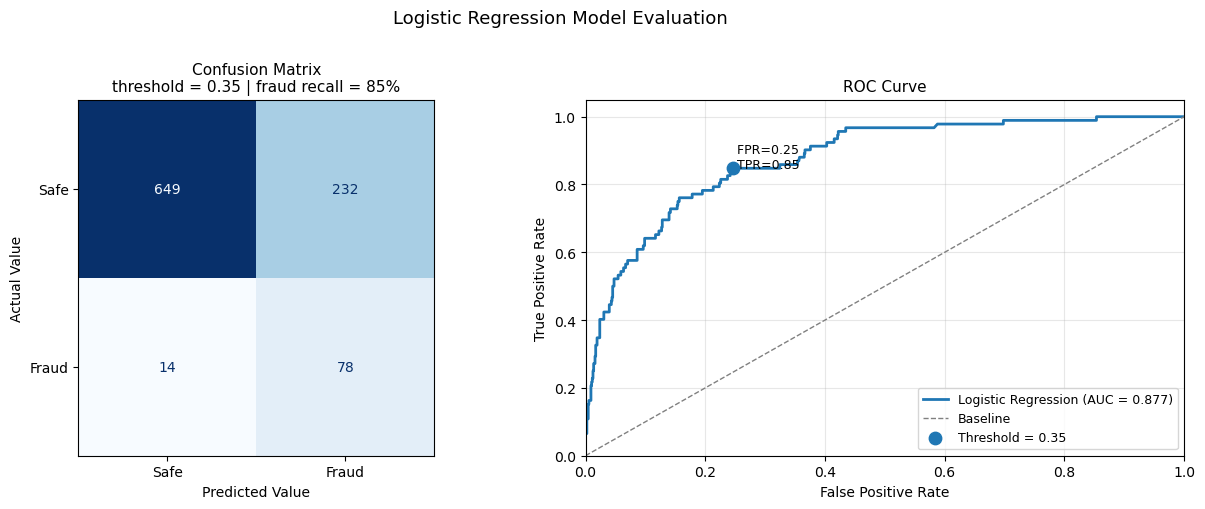

In [8]:
# =========================================================
# PHASE 2: SUBSETTING AND RETRAINING
# ON THE TOP 13
# =========================================================

core_features = [
    'institutional_friction',
    'credit_excluded',
    'expenditure_shock_capacity_yes_selling_assets',
    'edu_level_grouped_Middle School',
    'private_pension_asset',
    'qk6_clean',
    'saving_level_sophistication',
    'digital_onboarding_score',
    'advanced_fintech_intensity',
    'financial_planning_score',
    'household_size',
    'digital_skills_score',
    'saving_protection_score'
]

X_train_smote_13 = X_train_smote[core_features]
X_train_13 = X_train[core_features]
X_test_13 = X_test[core_features]

# =========================================================
# MODEL A: LOGISTIC REGRESSION
# =========================================================

# Sklearn
# (Predictions + ROC)
log_reg = LogisticRegression(
    max_iter=2000,
    random_state=42,
    class_weight='balanced'
)

log_reg.fit(
    X_train_13,
    y_train
)

# Statsmodels
# (Statistical inference)
X_train_sm = sm.add_constant(
    X_train_13
)

try:

    result = sm.Logit(
        y_train,
        X_train_sm
    ).fit(disp=False)

    infer_df = (
        pd.DataFrame({
            'Feature': result.params.index,
            'Coefficient': result.params.values,
            'Odds_Ratio': np.exp(result.params.values),
            'P_Value': result.pvalues.values
        })
        .query("Feature != 'const'")
        .assign(
            **{
                'Significant (p<0.05)':
                lambda d: d['P_Value'] < 0.05
            }
        )
        .sort_values(
            'Odds_Ratio',
            ascending=False
        )
    )

    print(
        "\n--- STATISTICAL INFERENCE: "
        "ODDS RATIO AND P-VALUE ---"
    )

    print(
        "Rule: Consider ONLY variables "
        "with Significant = True."
    )

    print(
        infer_df.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )

except Exception as e:

    print(
        f"\nStatsmodels did not converge "
        f"({e}) — sklearn odds ratio fallback"
    )

    infer_df = (
        pd.DataFrame({
            'Feature': core_features,
            'Odds_Ratio': np.exp(
                log_reg.coef_[0]
            )
        })
        .sort_values(
            'Odds_Ratio',
            ascending=False
        )
    )

    print(
        infer_df.to_string(
            index=False
        )
    )

# =========================================================
# ROC + CONFUSION MATRIX
# Unified two-panel figure
# =========================================================

from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

y_prob_log = log_reg.predict_proba(
    X_test_13
)[:, 1]

# Threshold selection
precisions, recalls, thresh_pr = (
    precision_recall_curve(
        y_test,
        y_prob_log
    )
)

THRESHOLD = 0.35

y_pred_log = (
    y_prob_log >= THRESHOLD
).astype(int)

print(
    f"\n--- LOGISTIC REGRESSION "
    f"PERFORMANCE "
    f"(threshold = {THRESHOLD:.3f}) ---"
)

print(
    classification_report(
        y_test,
        y_pred_log,
        target_names=[
            'Safe',
            'Fraud'
        ]
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

fig.suptitle(
    "Logistic Regression "
    "Model Evaluation",
    fontsize=13,
    y=1.01
)

# ----------------------------
# PANEL 1:
# Confusion Matrix
# ----------------------------

cm = confusion_matrix(
    y_test,
    y_pred_log
)

tn, fp, fn, tp = cm.ravel()

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        'Safe',
        'Fraud'
    ]
).plot(
    ax=axes[0],
    colorbar=False,
    cmap='Blues'
)

axes[0].set_title(
    f"Confusion Matrix\n"
    f"threshold = {THRESHOLD:.2f} | "
    f"fraud recall = {tp/(tp+fn):.0%}",
    fontsize=11
)

axes[0].set_xlabel(
    "Predicted Value"
)

axes[0].set_ylabel(
    "Actual Value"
)

# ----------------------------
# PANEL 2:
# ROC Curve
# ----------------------------

fpr, tpr, roc_thresh = roc_curve(
    y_test,
    y_prob_log
)

roc_auc_log = auc(
    fpr,
    tpr
)

axes[1].plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Logistic Regression '
          f'(AUC = {roc_auc_log:.3f})'
)

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1,
    color='grey',
    label='Baseline'
)

thresh_idx = np.argmin(
    np.abs(
        roc_thresh - THRESHOLD
    )
)

axes[1].scatter(
    fpr[thresh_idx],
    tpr[thresh_idx],
    zorder=5,
    s=80,
    label=f'Threshold = {THRESHOLD:.2f}'
)

axes[1].annotate(
    f" FPR={fpr[thresh_idx]:.2f}\n"
    f" TPR={tpr[thresh_idx]:.2f}",
    xy=(
        fpr[thresh_idx],
        tpr[thresh_idx]
    ),
    fontsize=9
)

axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

axes[1].set_xlabel(
    "False Positive Rate"
)

axes[1].set_ylabel(
    "True Positive Rate"
)

axes[1].set_title(
    "ROC Curve",
    fontsize=11
)

axes[1].legend(
    loc="lower right",
    fontsize=9
)

axes[1].grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [9]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV

# 1. Prepare the raw training set (BEFORE SMOTE),
# filtered to the selected 15 core features.
# We assume X_train, y_train, X_test, and core_features already exist in the environment.
X_train_13 = X_train[core_features]
X_test_13 = X_test[core_features]

# ==========================================
# GRID SEARCH FOR DECISION TREE (Transparency)
# ==========================================

# Build pipeline: SMOTE is applied dynamically within each CV fold
dt_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('dt', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

# Define hyperparameter grid
# Keep max_depth between 3 and 5 to avoid overly large,
# non-interpretable trees for presentation purposes
param_grid_dt = {
    'dt__max_depth': [3, 5, 7],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 5, 10],
    'dt__criterion': ['gini', 'entropy']
}

print("Starting Grid Search for Decision Tree...")

# scoring='recall' because we want to maximize fraud detection
grid_dt = GridSearchCV(
    dt_pipe,
    param_grid_dt,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_dt.fit(X_train_13, y_train)

print("\n--- BEST DECISION TREE PARAMETERS ---")
print(grid_dt.best_params_)

print(
    f"Best Recall (Cross-Validation): "
    f"{grid_dt.best_score_:.3f}"
)


# ==========================================
# GRID SEARCH FOR RANDOM FOREST (Pure Performance)
# ==========================================

rf_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

# Wider hyperparameter grid for Random Forest
# since it is not constrained to visual interpretability
param_grid_rf = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [4, 6, 8, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__max_features': ['sqrt', 'log2']
}

print(
    "\nStarting Grid Search for Random Forest "
    "(this may take a few minutes)..."
)

grid_rf = GridSearchCV(
    rf_pipe,
    param_grid_rf,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_rf.fit(X_train_13, y_train)

print("\n--- BEST RANDOM FOREST PARAMETERS ---")
print(grid_rf.best_params_)

print(
    f"Best Recall (Cross-Validation): "
    f"{grid_rf.best_score_:.3f}"
)


# ==========================================
# FINAL MODEL EVALUATION (ON TEST SET)
# ==========================================

# Extract best model from grid search
best_rf = grid_rf.best_estimator_

# Evaluate on untouched test set
y_pred_best_rf = best_rf.predict(X_test_13)

print("\n" + "=" * 50)
print("BEST RANDOM FOREST PERFORMANCE ON TEST SET")
print("=" * 50)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_rf))

Starting Grid Search for Decision Tree...

--- BEST DECISION TREE PARAMETERS ---
{'dt__criterion': 'entropy', 'dt__max_depth': 3, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}
Best Recall (Cross-Validation): 0.677

Starting Grid Search for Random Forest (this may take a few minutes)...

--- BEST RANDOM FOREST PARAMETERS ---
{'rf__max_depth': 4, 'rf__max_features': 'sqrt', 'rf__min_samples_split': 10, 'rf__n_estimators': 200}
Best Recall (Cross-Validation): 0.697

BEST RANDOM FOREST PERFORMANCE ON TEST SET

Confusion Matrix:
[[784  97]
 [ 33  59]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.89      0.92       881
           1       0.38      0.64      0.48        92

    accuracy                           0.87       973
   macro avg       0.67      0.77      0.70       973
weighted avg       0.90      0.87      0.88       973




--- RANDOM FOREST PERFORMANCE (threshold = 0.349) ---
              precision    recall  f1-score   support

        Safe       0.98      0.83      0.90       881
       Fraud       0.33      0.82      0.47        92

    accuracy                           0.83       973
   macro avg       0.65      0.82      0.68       973
weighted avg       0.92      0.83      0.86       973



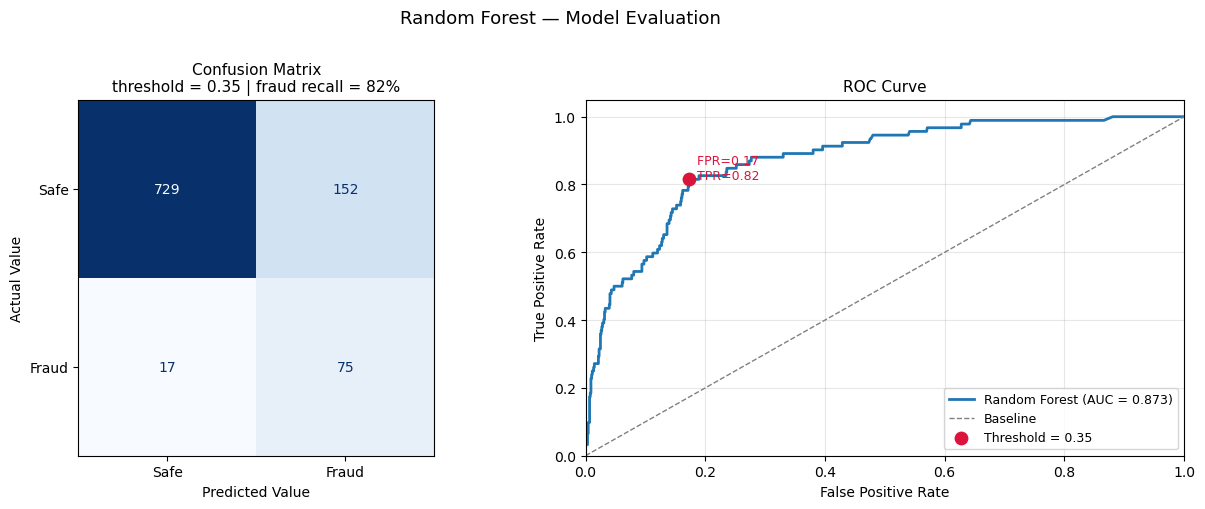

In [10]:
# Random Forest with best hyperparameters found
rf_best_model = RandomForestClassifier(
    n_estimators=grid_rf.best_params_['rf__n_estimators'],
    max_depth=grid_rf.best_params_['rf__max_depth'],
    min_samples_split=grid_rf.best_params_['rf__min_samples_split'],
    max_features=grid_rf.best_params_['rf__max_features'],
    random_state=42
)

rf_best_model.fit(X_train_smote_13, y_train_smote)
y_pred_best_rf = rf_best_model.predict(X_test_13)

# ============================
# CONFUSION MATRIX + ROC — RANDOM FOREST (optimized threshold)
# ============================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve
)

import matplotlib.pyplot as plt
import numpy as np

# --- raw predicted probabilities ---
y_prob_rf = rf_best_model.predict_proba(X_test_13)[:, 1]

# --- optimal F2 threshold (recall weighted higher than precision) ---
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf)

f2_scores = [
    (5 * p * r / (4 * p + r)) if (4 * p + r) > 0 else 0
    for p, r in zip(precisions[:-1], recalls[:-1])
]

best_thresh = thresholds[np.argmax(f2_scores)]

# --- optional manual override of threshold ---
THRESHOLD = best_thresh   # or e.g. 0.30 / 0.35

y_pred_rf = (y_prob_rf >= THRESHOLD).astype(int)

print(
    f"\n--- RANDOM FOREST PERFORMANCE "
    f"(threshold = {THRESHOLD:.3f}) ---"
)

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=['Safe', 'Fraud']
    )
)

# ── 2-panel figure ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Random Forest — Model Evaluation", fontsize=13, y=1.01)

# ── Panel 1: Confusion Matrix ────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()
recall_fraud = tp / (tp + fn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Safe', 'Fraud']
)

disp.plot(
    ax=axes[0],
    colorbar=False,
    cmap='Blues'
)

axes[0].set_title(
    f"Confusion Matrix\n"
    f"threshold = {THRESHOLD:.2f} | fraud recall = {recall_fraud:.0%}",
    fontsize=11
)

axes[0].set_xlabel("Predicted Value")
axes[0].set_ylabel("Actual Value")

# ── Panel 2: ROC + selected threshold point ─────────────────────────────────
fpr_rf, tpr_rf, roc_thresholds = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

axes[1].plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f'Random Forest (AUC = {roc_auc_rf:.3f})'
)

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1,
    color='grey',
    label='Baseline'
)

# point corresponding to chosen threshold on ROC curve
thresh_idx = np.argmin(np.abs(roc_thresholds - THRESHOLD))

axes[1].scatter(
    fpr_rf[thresh_idx],
    tpr_rf[thresh_idx],
    color='crimson',
    zorder=5,
    s=80,
    label=f'Threshold = {THRESHOLD:.2f}'
)

axes[1].annotate(
    f"  FPR={fpr_rf[thresh_idx]:.2f}\n"
    f"  TPR={tpr_rf[thresh_idx]:.2f}",
    xy=(fpr_rf[thresh_idx], tpr_rf[thresh_idx]),
    fontsize=9,
    color='crimson'
)

axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontsize=11)

axes[1].legend(loc="lower right", fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


--- DECISION TREE PERFORMANCE (threshold = 0.350) ---
              precision    recall  f1-score   support

        Safe       0.96      0.90      0.93       881
       Fraud       0.39      0.60      0.47        92

    accuracy                           0.87       973
   macro avg       0.67      0.75      0.70       973
weighted avg       0.90      0.87      0.88       973



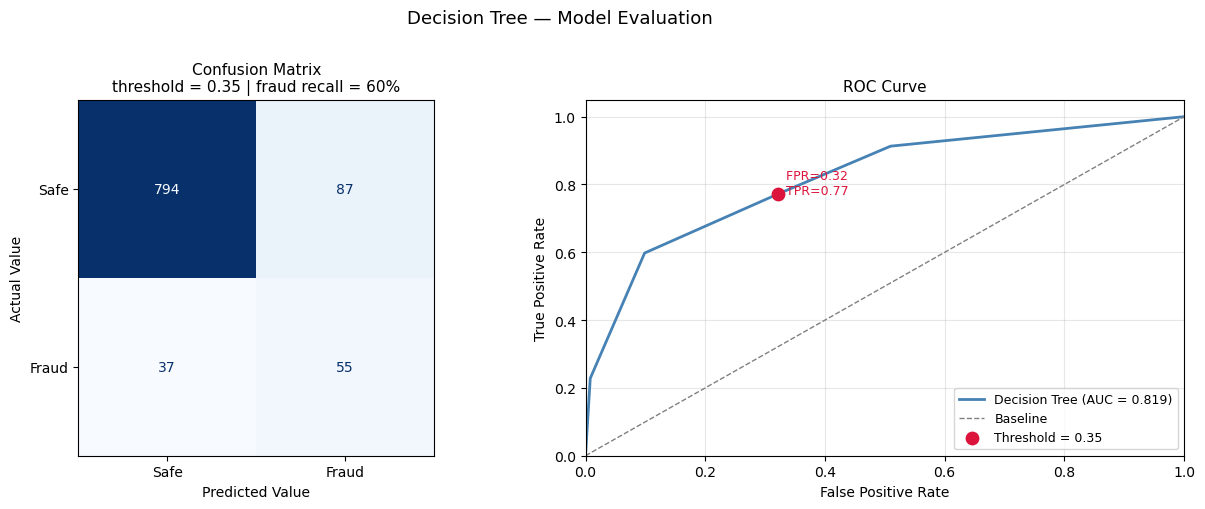

In [11]:
# {'dt__criterion': 'entropy', 'dt__max_depth': 3,
#  'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}

dt_best_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced"
)

dt_best_model.fit(X_train_smote_13, y_train_smote)
y_pred_best_dt = dt_best_model.predict(X_test_13)

# --- raw predicted probabilities ---
y_prob_dt = dt_best_model.predict_proba(X_test_13)[:, 1]

# --- optimal F2 threshold ---
# NOTE: With max_depth=3, the decision tree produces
# stepwise probabilities (few distinct values),
# so the PR curve is less smooth than RF/LogReg —
# expected behavior, not a bug.
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_dt)

f2_scores = [
    (5 * p * r / (4 * p + r)) if (4 * p + r) > 0 else 0
    for p, r in zip(precisions[:-1], recalls[:-1])
]

THRESHOLD = 0.35   # or manually set, e.g. 0.35

y_pred_dt = (y_prob_dt >= THRESHOLD).astype(int)

print(
    f"\n--- DECISION TREE PERFORMANCE "
    f"(threshold = {THRESHOLD:.3f}) ---"
)

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=['Safe', 'Fraud']
    )
)

# ── 2-panel figure ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Decision Tree — Model Evaluation", fontsize=13, y=1.01)

# ── Panel 1: Confusion Matrix ────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_dt)
tn, fp, fn, tp = cm.ravel()
recall_fraud = tp / (tp + fn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Safe', 'Fraud']
)

disp.plot(
    ax=axes[0],
    colorbar=False,
    cmap='Blues'
)

axes[0].set_title(
    f"Confusion Matrix\n"
    f"threshold = {THRESHOLD:.2f} | fraud recall = {recall_fraud:.0%}",
    fontsize=11
)

axes[0].set_xlabel("Predicted Value")
axes[0].set_ylabel("Actual Value")

# ── Panel 2: ROC + threshold point ───────────────────────────────────────────
fpr_dt, tpr_dt, roc_thresholds = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

axes[1].plot(
    fpr_dt,
    tpr_dt,
    linewidth=2,
    color='steelblue',
    label=f'Decision Tree (AUC = {roc_auc_dt:.3f})'
)

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1,
    color='grey',
    label='Baseline'
)

# threshold point on ROC curve
thresh_idx = np.argmin(np.abs(roc_thresholds - THRESHOLD))

axes[1].scatter(
    fpr_dt[thresh_idx],
    tpr_dt[thresh_idx],
    color='crimson',
    zorder=5,
    s=80,
    label=f'Threshold = {THRESHOLD:.2f}'
)

axes[1].annotate(
    f"  FPR={fpr_dt[thresh_idx]:.2f}\n"
    f"  TPR={tpr_dt[thresh_idx]:.2f}",
    xy=(fpr_dt[thresh_idx], tpr_dt[thresh_idx]),
    fontsize=9,
    color='crimson'
)

axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontsize=11)

axes[1].legend(loc="lower right", fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Generazione SHAP Values...


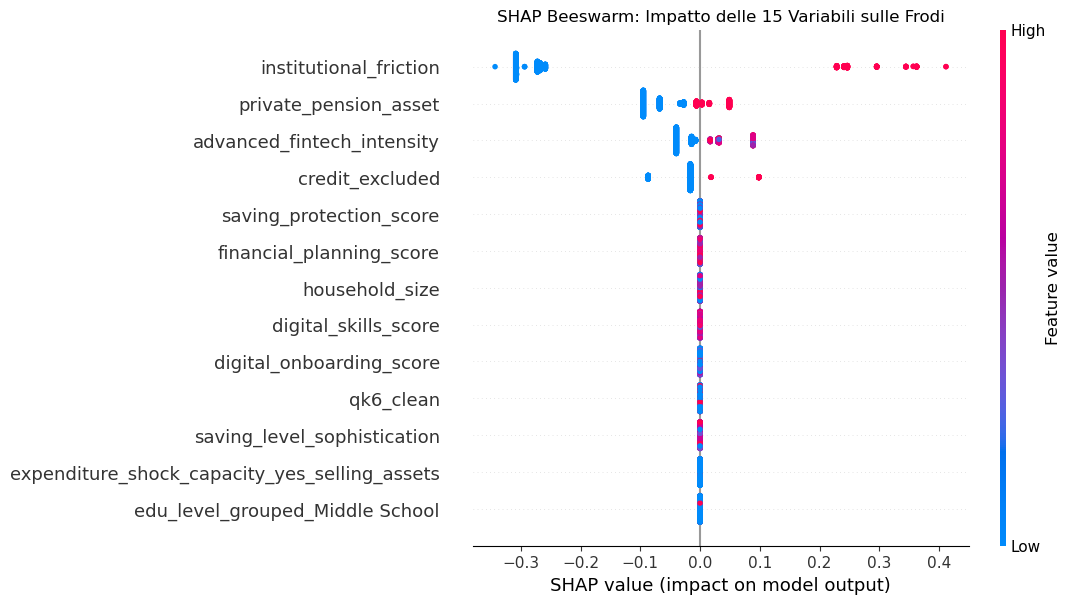

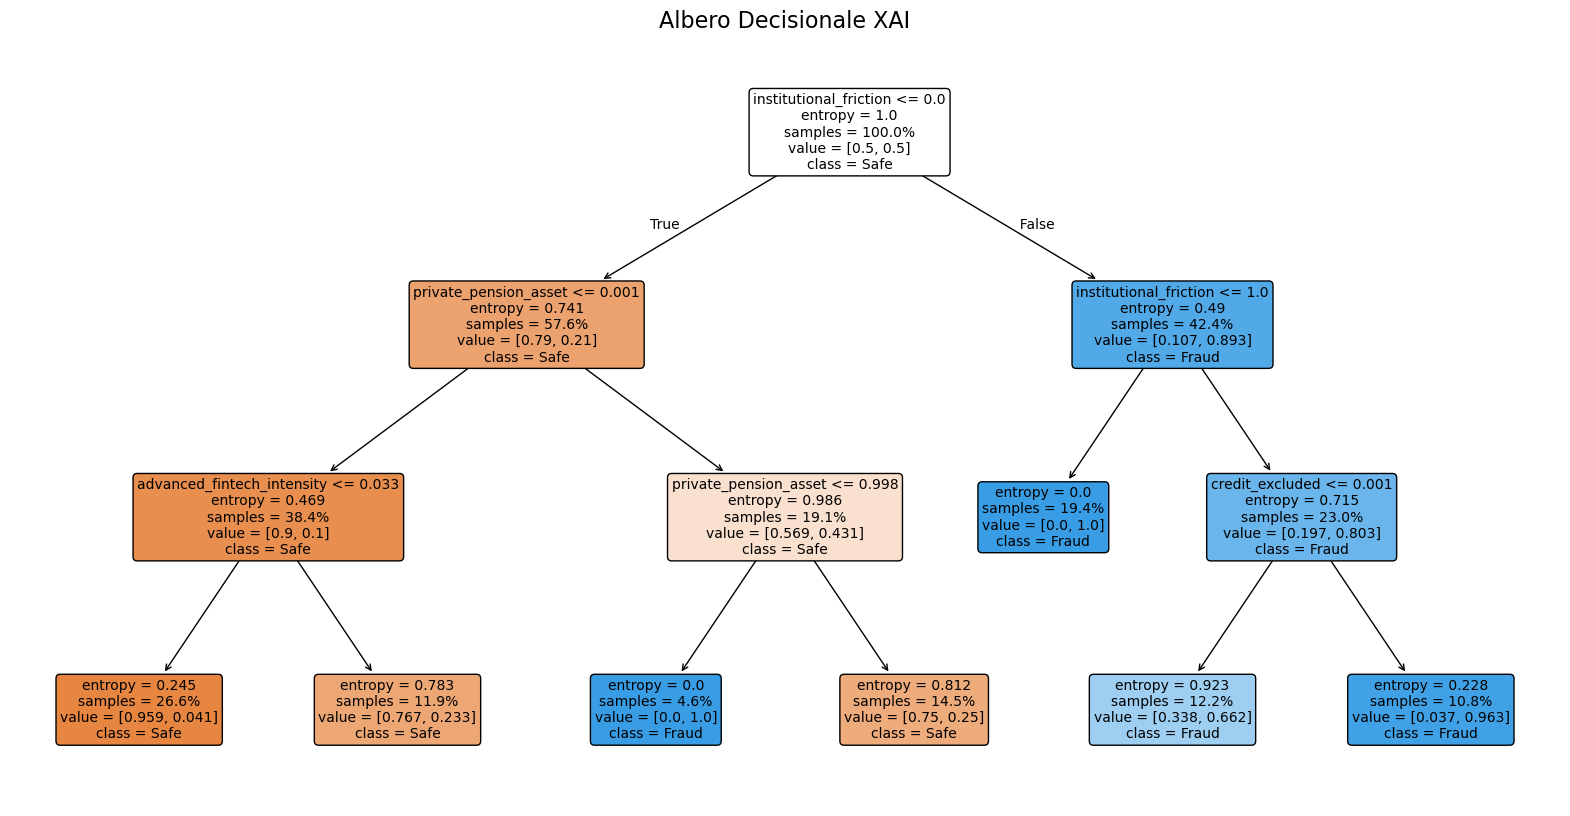

In [12]:
# XAI: SHAP Beeswarm Plot (Sull'Albero e sul Test Set)
print("\nGenerazione SHAP Values...")
explainer = shap.TreeExplainer(dt_best_model)
shap_values = explainer(X_test_13)

plt.figure()
plt.title("SHAP Beeswarm: Impatto delle 15 Variabili sulle Frodi")
try:
    shap.plots.beeswarm(shap_values[:, :, 1], max_display=15)
except:
    shap.plots.beeswarm(shap_values, max_display=15)

# Visualizzazione Albero
plt.figure(figsize=(20, 10))
plot_tree(dt_best_model, feature_names=core_features, class_names=['Safe', 'Fraud'], 
          filled=True, rounded=True, proportion=True, fontsize=10)
plt.title("Albero Decisionale XAI", fontsize=16)
plt.show()

TP: 78 | FN: 14 | FP: 232 | TN: 649
Fraud recall: 85%

Sizes: TP=78 | FN=14

--- MEAN COMPARISON: TP vs FN (numerical variables) ---
                    Feature  Mean_TP  Mean_FN  Delta  p_value Sig
 advanced_fintech_intensity    2.449    0.929 -1.520    0.002 ***
   digital_onboarding_score    1.590    0.429 -1.161    0.006 ***
   financial_planning_score    4.282    2.929 -1.353    0.016   *
             household_size    2.974    3.714  0.740    0.069   —
saving_level_sophistication    2.231    1.857 -0.374    0.076   —
                  qk6_clean    0.590    0.357 -0.233    0.110   —
    saving_protection_score    0.436    0.714  0.278    0.411   —
       digital_skills_score    2.813    2.704 -0.109    0.987   —

--- FREQUENCY COMPARISON: TP vs FN (categorical variables) ---
                                      Feature  Pct_TP  Pct_FN  Delta  p_value Sig
                       institutional_friction   0.705   0.000 -0.705    0.000 ***
                        private_pension_asset

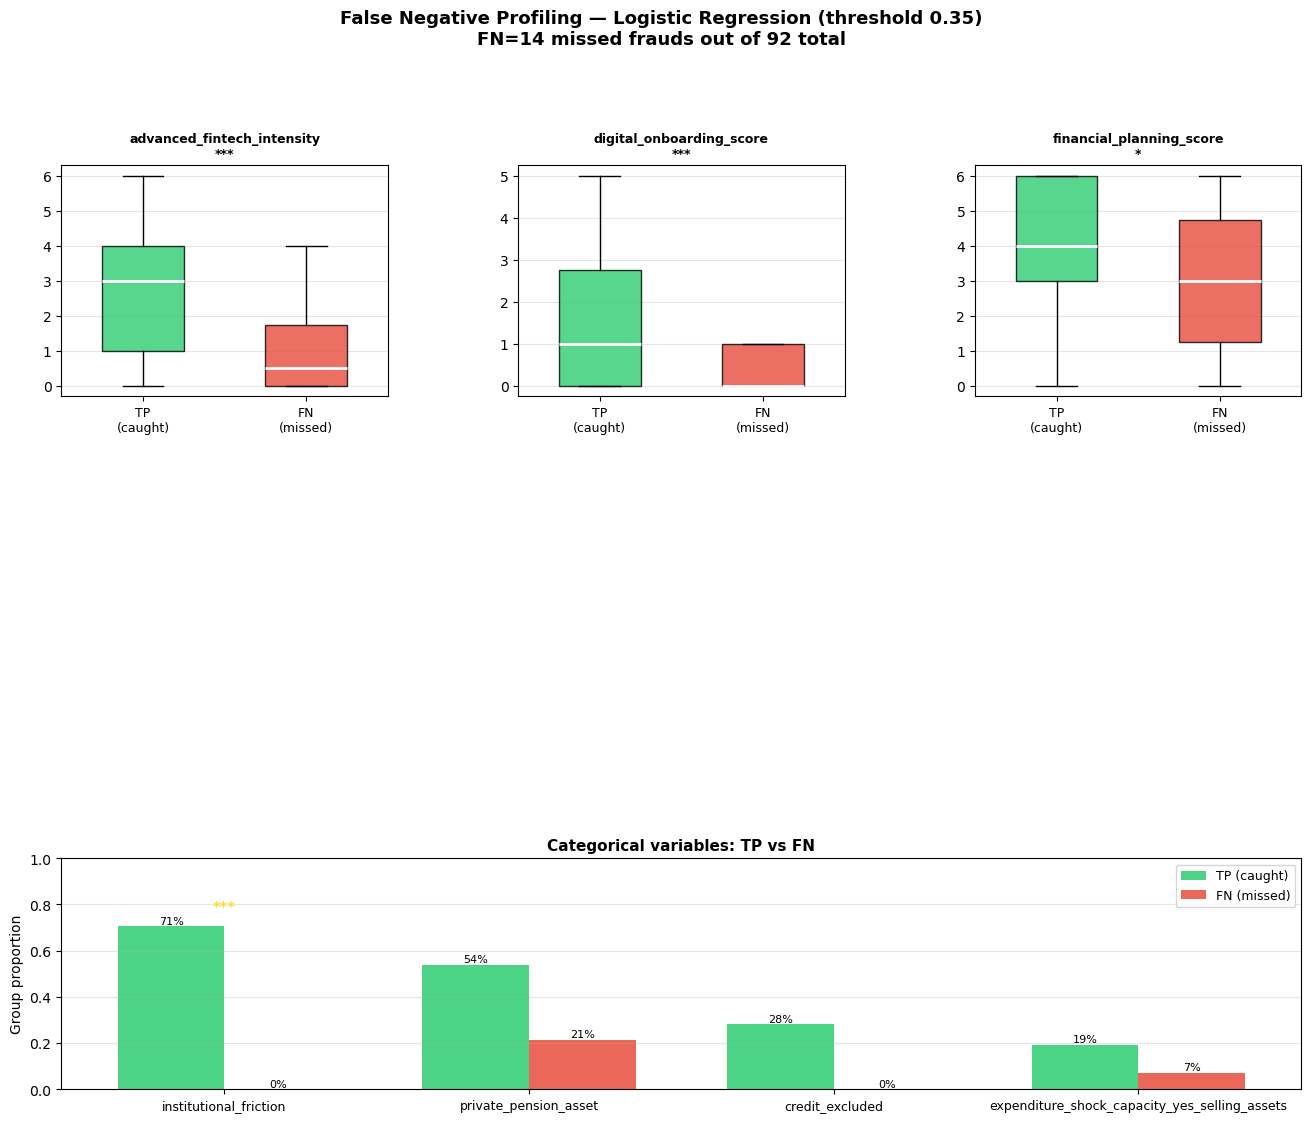


SUMMARY — PROFILE OF THE INVISIBLE FRAUD CASES

Numerical variables differentiating FN vs TP:
                   Feature  Mean_TP  Mean_FN  Delta Sig
advanced_fintech_intensity    2.449    0.929 -1.520 ***
  digital_onboarding_score    1.590    0.429 -1.161 ***
  financial_planning_score    4.282    2.929 -1.353   *

Categorical variables differentiating FN vs TP:
               Feature  Pct_TP  Pct_FN  Delta Sig
institutional_friction   0.705   0.000 -0.705 ***

Model-assigned probability:
  TP: 0.776 → FN: 0.245

Interpretation: false negatives are cases the model considers
'almost safe' — low predicted probability but actual frauds.
Features with negative Delta indicate cases where FN
resemble non-fraud observations, confusing the model.


In [13]:
# =========================================================
# FALSE NEGATIVE PROFILING — LOGISTIC REGRESSION (threshold 0.35)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import mannwhitneyu, chi2_contingency
import warnings

warnings.filterwarnings('ignore')

THRESHOLD = 0.35

# ── 1. RECONSTRUCT CLASSIFICATION LABELS ─────────────────────────────────────
y_prob_log = log_reg.predict_proba(X_test_13)[:, 1]
y_pred_035 = (y_prob_log >= THRESHOLD).astype(int)
y_test_arr = np.array(y_test)

# Masks for confusion matrix quadrants
mask_TP = (y_test_arr == 1) & (y_pred_035 == 1)   # fraud correctly detected ✓
mask_FN = (y_test_arr == 1) & (y_pred_035 == 0)   # missed fraud ✗
mask_FP = (y_test_arr == 0) & (y_pred_035 == 1)   # false alarm
mask_TN = (y_test_arr == 0) & (y_pred_035 == 0)   # correct safe

print(
    f"TP: {mask_TP.sum()} | FN: {mask_FN.sum()} | "
    f"FP: {mask_FP.sum()} | TN: {mask_TN.sum()}"
)

print(
    f"Fraud recall: "
    f"{mask_TP.sum() / (mask_TP.sum() + mask_FN.sum()):.0%}"
)

# ── 2. WORKING DATAFRAME (test set + labels) ─────────────────────────────────
df_test = X_test_13.copy().reset_index(drop=True)
df_test['y_true'] = y_test_arr
df_test['y_pred'] = y_pred_035
df_test['prob_fraud'] = y_prob_log
df_test['quadrant'] = 'TN'

df_test.loc[mask_TP, 'quadrant'] = 'TP'
df_test.loc[mask_FN, 'quadrant'] = 'FN'
df_test.loc[mask_FP, 'quadrant'] = 'FP'

# Subsets TP and FN (focus groups)
df_TP = df_test[df_test['quadrant'] == 'TP']
df_FN = df_test[df_test['quadrant'] == 'FN']

print(f"\nSizes: TP={len(df_TP)} | FN={len(df_FN)}")

# ── 3. NUMERICAL COMPARISON TP vs FN ────────────────────────────────────────
numeric_features = [
    'digital_onboarding_score',
    'advanced_fintech_intensity',
    'financial_planning_score',
    'digital_skills_score',
    'saving_level_sophistication',
    'saving_protection_score',
    'household_size',
    'qk6_clean'
]

print("\n--- MEAN COMPARISON: TP vs FN (numerical variables) ---")

rows = []

for feat in numeric_features:
    tp_vals = df_TP[feat].dropna()
    fn_vals = df_FN[feat].dropna()

    stat, p = mannwhitneyu(tp_vals, fn_vals, alternative='two-sided')

    rows.append({
        'Feature': feat,
        'Mean_TP': tp_vals.mean(),
        'Mean_FN': fn_vals.mean(),
        'Delta': fn_vals.mean() - tp_vals.mean(),
        'p_value': p,
        'Sig': '***' if p < 0.01 else ('*' if p < 0.05 else '—')
    })

num_df = pd.DataFrame(rows).sort_values('p_value')

print(
    num_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)

# ── 4. CATEGORICAL COMPARISON TP vs FN ──────────────────────────────────────
cat_features = [
    'institutional_friction',
    'credit_excluded',
    'private_pension_asset',
    'expenditure_shock_capacity_yes_selling_assets'
]

print("\n--- FREQUENCY COMPARISON: TP vs FN (categorical variables) ---")

cat_rows = []

for feat in cat_features:
    pct_tp = df_TP[feat].mean()
    pct_fn = df_FN[feat].mean()

    ct = pd.crosstab(
        df_test.loc[df_test['quadrant'].isin(['TP', 'FN']), 'quadrant'],
        df_test.loc[df_test['quadrant'].isin(['TP', 'FN']), feat]
    )

    if ct.shape == (2, 2):
        _, p, _, _ = chi2_contingency(ct)
    else:
        p = np.nan

    cat_rows.append({
        'Feature': feat,
        'Pct_TP': pct_tp,
        'Pct_FN': pct_fn,
        'Delta': pct_fn - pct_tp,
        'p_value': p,
        'Sig': '***' if p < 0.01 else ('*' if p < 0.05 else '—')
    })

cat_df = pd.DataFrame(cat_rows).sort_values('p_value')

print(
    cat_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)

# ── 5. MODEL ASSIGNED PROBABILITIES ─────────────────────────────────────────
print("\n--- MODEL ASSIGNED PROBABILITIES ---")

print(
    f"TP (detected frauds): mean prob = {df_TP['prob_fraud'].mean():.3f} "
    f"| min = {df_TP['prob_fraud'].min():.3f} "
    f"| max = {df_TP['prob_fraud'].max():.3f}"
)

print(
    f"FN (missed frauds): mean prob = {df_FN['prob_fraud'].mean():.3f} "
    f"| min = {df_FN['prob_fraud'].min():.3f} "
    f"| max = {df_FN['prob_fraud'].max():.3f}"
)

# ── 6. VISUALIZATION ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

colors = {'TP': '#2ecc71', 'FN': '#e74c3c'}

# Boxplots for top numerical features
top_num = num_df[num_df['Sig'] != '—']['Feature'].tolist()[:6]
if not top_num:
    top_num = num_df['Feature'].tolist()[:6]

for i, feat in enumerate(top_num):
    row, col = divmod(i, 3)
    ax = fig.add_subplot(gs[row, col])

    data = [df_TP[feat].dropna(), df_FN[feat].dropna()]

    bp = ax.boxplot(
        data,
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color='white', linewidth=2)
    )

    for patch, c in zip(bp['boxes'], [colors['TP'], colors['FN']]):
        patch.set_facecolor(c)
        patch.set_alpha(0.8)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['TP\n(caught)', 'FN\n(missed)'], fontsize=9)

    sig_tag = num_df.loc[num_df['Feature'] == feat, 'Sig'].values[0]

    ax.set_title(
        f"{feat}\n{sig_tag}",
        fontsize=9,
        fontweight='bold'
    )

    ax.grid(axis='y', alpha=0.3)

# Barplot categorical variables
ax_bar = fig.add_subplot(gs[2, :])

x = np.arange(len(cat_features))
width = 0.35

bars_tp = ax_bar.bar(
    x - width/2,
    cat_df['Pct_TP'],
    width,
    label='TP (caught)',
    color=colors['TP'],
    alpha=0.85
)

bars_fn = ax_bar.bar(
    x + width/2,
    cat_df['Pct_FN'],
    width,
    label='FN (missed)',
    color=colors['FN'],
    alpha=0.85
)

# Percentage labels
for bar in bars_tp:
    ax_bar.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.0%}",
        ha='center',
        fontsize=8
    )

for bar in bars_fn:
    ax_bar.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.0%}",
        ha='center',
        fontsize=8
    )

# Significance markers
for j, row in cat_df.reset_index(drop=True).iterrows():
    if row['Sig'] != '—':
        y_max = max(row['Pct_TP'], row['Pct_FN']) + 0.06
        ax_bar.text(j, y_max, row['Sig'],
                    ha='center',
                    fontsize=11,
                    color='gold')

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(cat_df['Feature'].tolist(), fontsize=9)
ax_bar.set_ylabel("Group proportion")
ax_bar.set_title("Categorical variables: TP vs FN",
                 fontsize=11, fontweight='bold')
ax_bar.legend(fontsize=9)
ax_bar.set_ylim(0, 1)
ax_bar.grid(axis='y', alpha=0.3)

fig.suptitle(
    f"False Negative Profiling — Logistic Regression (threshold {THRESHOLD})\n"
    f"FN={mask_FN.sum()} missed frauds out of {(y_test_arr==1).sum()} total",
    fontsize=13,
    fontweight='bold',
    y=1.01
)

plt.show()

# ── 7. NARRATIVE SUMMARY ────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY — PROFILE OF THE INVISIBLE FRAUD CASES")
print("=" * 60)

sig_num = num_df[num_df['Sig'] != '—'][['Feature','Mean_TP','Mean_FN','Delta','Sig']]
sig_cat = cat_df[cat_df['Sig'] != '—'][['Feature','Pct_TP','Pct_FN','Delta','Sig']]

if not sig_num.empty:
    print("\nNumerical variables differentiating FN vs TP:")
    print(sig_num.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

if not sig_cat.empty:
    print("\nCategorical variables differentiating FN vs TP:")
    print(sig_cat.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("\nModel-assigned probability:")
print(f"  TP: {df_TP['prob_fraud'].mean():.3f} → FN: {df_FN['prob_fraud'].mean():.3f}")

print("\nInterpretation: false negatives are cases the model considers")
print("'almost safe' — low predicted probability but actual frauds.")

print("Features with negative Delta indicate cases where FN")
print("resemble non-fraud observations, confusing the model.")

### Cost Analysis ###

In [14]:
# =========================================================
# COST-SENSITIVE LEARNING — Setup
# =========================================================

# Alternative to SMOTE: instead of rebalancing the dataset,
# we make the model explicitly aware of asymmetric error costs.
# More realistic for banking fraud detection.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings

warnings.filterwarnings('ignore')

# ── Cost matrix definition ───────────────────────────────
# Context: banking fraud detection for customer retention
#
#               Predicted Safe     Predicted Fraud
# Actual Safe        0                  1        ← FP: false alarm (customer friction)
# Actual Fraud       5                  0        ← FN: missed fraud (financial + reputational loss)
#
# FN:FP ratio = 5:1 (conservative, aligned with banking literature)

COST_FN = 5    # cost of missed fraud
COST_FP = 1    # cost of false alarm

# Equivalent class weights: class 1 (fraud) weight = COST_FN
cost_weights = {0: COST_FP, 1: COST_FN}

print("Cost matrix defined:")
print(f"  False Negative (missed fraud) → cost {COST_FN}")
print(f"  False Positive (false alarm) → cost {COST_FP}")
print(f"  FN:FP ratio = {COST_FN}:{COST_FP}")

print("\nNote: models are trained on ORIGINAL X_train")
print("(without SMOTE) — class imbalance is handled")
print("entirely through loss function weighting.")

Cost matrix defined:
  False Negative (missed fraud) → cost 5
  False Positive (false alarm) → cost 1
  FN:FP ratio = 5:1

Note: models are trained on ORIGINAL X_train
(without SMOTE) — class imbalance is handled
entirely through loss function weighting.


In [15]:
# =========================================================
# GRID SEARCH — COST-SENSITIVE DECISION TREE
# (to be placed BEFORE Cell 2 - Cost-Sensitive Training)
# =========================================================

# Note: separate grid from the SMOTE-based setup because the
# learning context is different — original imbalanced data
# with asymmetric cost weighting.
#
# Higher max_depth values are explored: without SMOTE,
# fraud signal is weaker and deeper trees may be required.

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold

param_grid_dt_cost = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 8],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
}

grid_dt_cost = GridSearchCV(
    estimator=DecisionTreeClassifier(
        class_weight=cost_weights,  # fixed — business decision, not tuned
        random_state=42
    ),
    param_grid=param_grid_dt_cost,
    scoring='f1',  # F1 score for fraud class, consistent with previous setup
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),
    n_jobs=-1,
    verbose=1
)

grid_dt_cost.fit(X_train_13, y_train)  # original training set, no SMOTE

print("\nBest cost-sensitive Decision Tree parameters:")
print(grid_dt_cost.best_params_)

print(f"Best CV F1 score: {grid_dt_cost.best_score_:.4f}")

Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best cost-sensitive Decision Tree parameters:
{'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1 score: 0.5052


In [16]:
# =========================================================
# GRID SEARCH — COST-SENSITIVE RANDOM FOREST
# (to be placed AFTER DT GridSearch, BEFORE Cell 2)
# =========================================================

param_grid_rf_cost = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 10, 20],
    'max_features': ['sqrt', 'log2'],
}

grid_rf_cost = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight=cost_weights,  # fixed — business decision
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_rf_cost,
    scoring='f1',
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),
    n_jobs=-1,
    verbose=1
)

grid_rf_cost.fit(X_train_13, y_train)  # original training set, no SMOTE

print("\nBest cost-sensitive Random Forest parameters:")
print(grid_rf_cost.best_params_)

print(f"Best CV F1 score: {grid_rf_cost.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best cost-sensitive Random Forest parameters:
{'max_depth': 6, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best CV F1 score: 0.5509


In [17]:
# =========================================================
# COST-SENSITIVE TRAINING (no SMOTE, original data)
# =========================================================

THRESHOLD = 0.35  # same threshold used in previous models

# ── Cost-sensitive Logistic Regression ───────────────────
log_cost = LogisticRegression(
    class_weight=cost_weights,
    max_iter=2000,
    random_state=42
)
log_cost.fit(X_train_13, y_train)

# ── Cost-sensitive Decision Tree ─────────────────────────
# (hyperparameters from updated Grid Search)
dt_cost = DecisionTreeClassifier(
    criterion=grid_dt_cost.best_params_['criterion'],
    max_depth=grid_dt_cost.best_params_['max_depth'],
    min_samples_split=grid_dt_cost.best_params_['min_samples_split'],
    min_samples_leaf=grid_dt_cost.best_params_['min_samples_leaf'],
    class_weight=cost_weights,
    random_state=42
)
dt_cost.fit(X_train_13, y_train)

# ── Cost-sensitive Random Forest ─────────────────────────
# (hyperparameters from updated Grid Search)
rf_cost = RandomForestClassifier(
    n_estimators=grid_rf_cost.best_params_['n_estimators'],
    max_depth=grid_rf_cost.best_params_['max_depth'],
    min_samples_split=grid_rf_cost.best_params_['min_samples_split'],
    max_features=grid_rf_cost.best_params_['max_features'],
    class_weight=cost_weights,
    random_state=42,
    n_jobs=-1
)
rf_cost.fit(X_train_13, y_train)

# ── Test set probabilities ───────────────────────────────
probs = {
    'LogReg': log_cost.predict_proba(X_test_13)[:, 1],
    'DT': dt_cost.predict_proba(X_test_13)[:, 1],
    'RF': rf_cost.predict_proba(X_test_13)[:, 1],
}

print("Training completed for all cost-sensitive models.")
print(f"Classification threshold: {THRESHOLD}")

Training completed for all cost-sensitive models.
Classification threshold: 0.35


In [21]:
# =========================================================
# EVALUATION: PERFORMANCE + TOTAL ERROR COST
# =========================================================

def evaluate_cost(name, y_true, y_prob, threshold, cost_fn, cost_fp):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    total_cost = fn * cost_fn + fp * cost_fp

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    f2 = (
        (5 * precision * recall / (4 * precision + recall))
        if (4 * precision + recall) > 0 else 0
    )

    roc_auc = auc(*roc_curve(y_true, y_prob)[:2])

    return {
        'Model': name,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Recall': recall,
        'Precision': precision,
        'F2': f2,
        'AUC': roc_auc,
        'Cost_FN': fn * cost_fn,
        'Cost_FP': fp * cost_fp,
        'Total_Cost': total_cost,
    }

results_cost = pd.DataFrame([
    evaluate_cost('LogReg cost', y_test, probs['LogReg'], THRESHOLD, COST_FN, COST_FP),
    evaluate_cost('DT cost',     y_test, probs['DT'],     THRESHOLD, COST_FN, COST_FP),
    evaluate_cost('RF cost',     y_test, probs['RF'],     THRESHOLD, COST_FN, COST_FP),
])

print("\n--- COST-SENSITIVE MODEL PERFORMANCE ---")

print(
    results_cost[
        ['Model','TP','FP','FN','TN',
         'Recall','Precision','F2','AUC']
    ].to_string(index=False, float_format=lambda x: f"{x:.3f}")
)

print("\n--- TOTAL ERROR COST ---")

print(
    results_cost[
        ['Model','FN','Cost_FN',
         'FP','Cost_FP','Total_Cost']
    ].to_string(index=False, float_format=lambda x: f"{x:.1f}")
)

print("\nCost interpretation:")
print(f"  Cost_FN = FN × {COST_FN}  (fraud + reputational damage)")
print(f"  Cost_FP = FP × {COST_FP}  (customer friction)")
print("  The model with the lowest Total_Cost is optimal for the bank.")


--- COST-SENSITIVE MODEL PERFORMANCE ---
      Model  TP  FP  FN  TN  Recall  Precision    F2   AUC
LogReg cost  64 120  28 761   0.696      0.348 0.580 0.877
    DT cost  61 134  31 747   0.663      0.313 0.542 0.785
    RF cost  64 105  28 776   0.696      0.379 0.596 0.882

--- TOTAL ERROR COST ---
      Model  FN  Cost_FN  FP  Cost_FP  Total_Cost
LogReg cost  28      140 120      120         260
    DT cost  31      155 134      134         289
    RF cost  28      140 105      105         245

Cost interpretation:
  Cost_FN = FN × 5  (fraud + reputational damage)
  Cost_FP = FP × 1  (customer friction)
  The model with the lowest Total_Cost is optimal for the bank.



--- SMOTE vs COST MATRIX: TOTAL COST COMPARISON ---
       Model    Approach  Recall   AUC  Cost_FN  Cost_FP  Total_Cost
LogReg SMOTE       SMOTE   0.848 0.877       70      232         302
    DT SMOTE       SMOTE   0.598 0.819      185       87         272
    RF SMOTE       SMOTE   0.793 0.873       95      152         247
 LogReg cost Cost Matrix   0.696 0.877      140      120         260
     DT cost Cost Matrix   0.663 0.785      155      134         289
     RF cost Cost Matrix   0.696 0.882      140      105         245


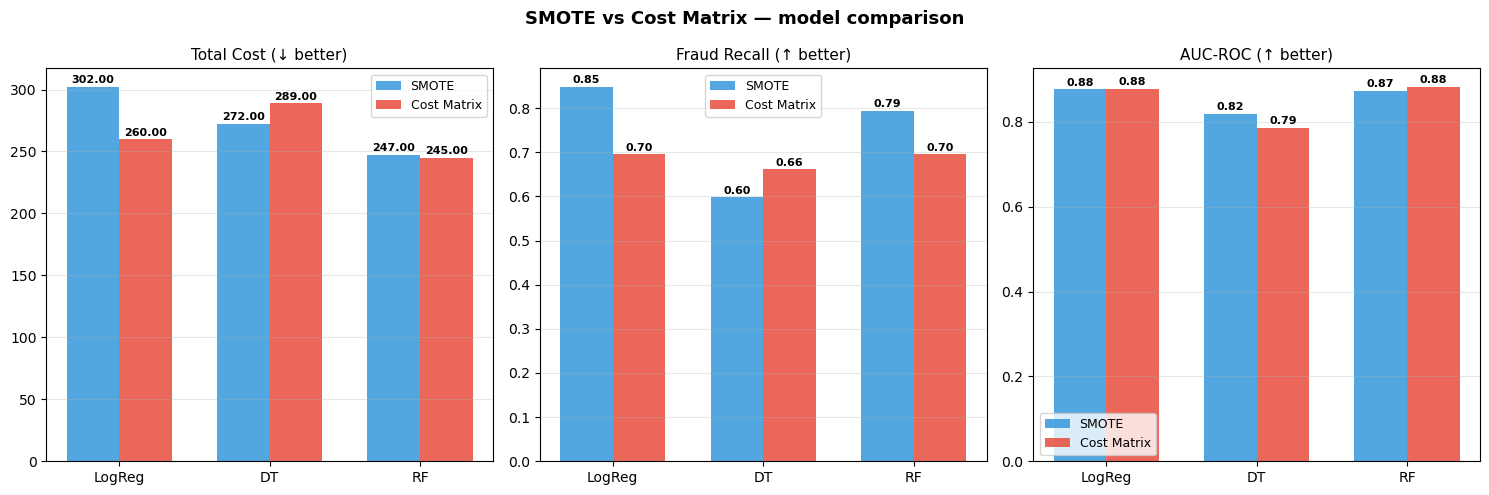

In [22]:
# =========================================================
# DIRECT COMPARISON: SMOTE vs COST MATRIX
# =========================================================

# SMOTE models are those already trained in the notebook:
# rf_best_model, dt_best_model, log_reg (with class_weight='balanced')

results_smote = pd.DataFrame([
    evaluate_cost(
        'LogReg SMOTE',
        y_test,
        log_reg.predict_proba(X_test_13)[:, 1],
        THRESHOLD,
        COST_FN,
        COST_FP
    ),
    evaluate_cost(
        'DT SMOTE',
        y_test,
        dt_best_model.predict_proba(X_test_13)[:, 1],
        THRESHOLD,
        COST_FN,
        COST_FP
    ),
    evaluate_cost(
        'RF SMOTE',
        y_test,
        rf_best_model.predict_proba(X_test_13)[:, 1],
        THRESHOLD,
        COST_FN,
        COST_FP
    ),
])

comparison = pd.concat([results_smote, results_cost], ignore_index=True)
comparison['Approach'] = (['SMOTE'] * 3 + ['Cost Matrix'] * 3)

print("\n--- SMOTE vs COST MATRIX: TOTAL COST COMPARISON ---")

pivot = comparison[
    ['Model', 'Approach', 'Recall', 'AUC',
     'Cost_FN', 'Cost_FP', 'Total_Cost']
]

print(pivot.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# ── Visualization comparison ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "SMOTE vs Cost Matrix — model comparison",
    fontsize=13,
    fontweight='bold'
)

models  = ['LogReg', 'DT', 'RF']
metrics = ['Total_Cost', 'Recall', 'AUC']
titles  = ['Total Cost (↓ better)', 'Fraud Recall (↑ better)', 'AUC-ROC (↑ better)']

colors = {'SMOTE': '#3498db', 'Cost Matrix': '#e74c3c'}

for ax, metric, title in zip(axes, metrics, titles):
    x = np.arange(len(models))
    width = 0.35

    for i, approach in enumerate(['SMOTE', 'Cost Matrix']):
        vals = comparison[comparison['Approach'] == approach][metric].values

        bars = ax.bar(
            x + (i - 0.5) * width,
            vals,
            width,
            label=approach,
            color=colors[approach],
            alpha=0.85
        )

        for bar, v in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                f"{v:.2f}",
                ha='center',
                fontsize=8,
                fontweight='bold'
            )

    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

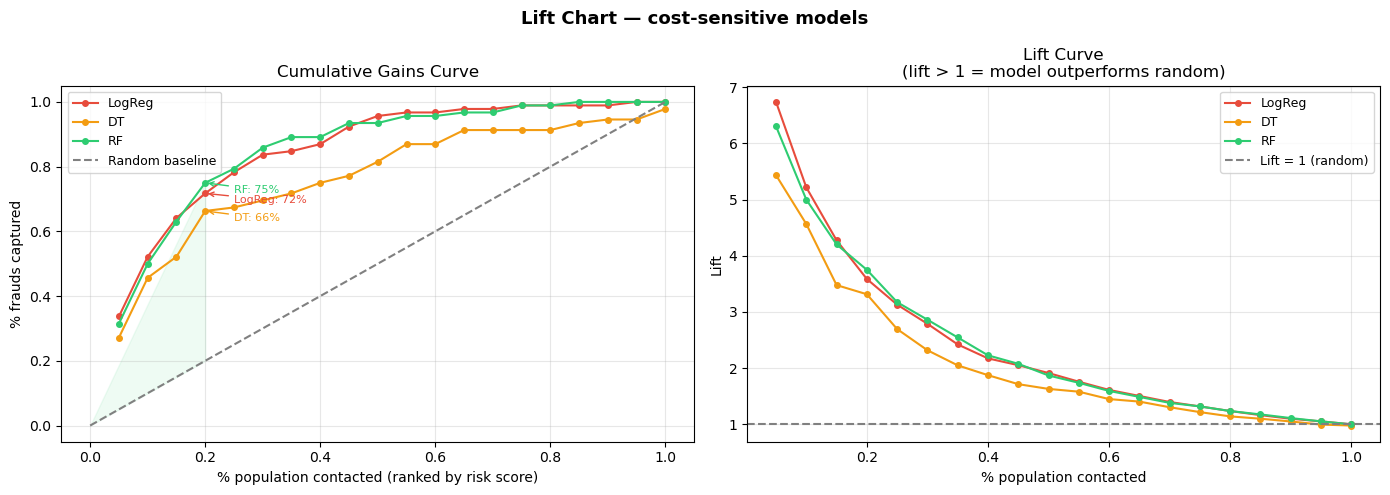


--- LIFT IN TOP 3 DECILES (top 10%, 20%, 30%) ---
  LogReg | top 10% → captures 52% of frauds (lift = 5.22x)
  LogReg | top 20% → captures 72% of frauds (lift = 3.59x)
  LogReg | top 30% → captures 84% of frauds (lift = 2.79x)

  DT | top 10% → captures 46% of frauds (lift = 4.57x)
  DT | top 20% → captures 66% of frauds (lift = 3.32x)
  DT | top 30% → captures 70% of frauds (lift = 2.32x)

  RF | top 10% → captures 50% of frauds (lift = 5.00x)
  RF | top 20% → captures 75% of frauds (lift = 3.75x)
  RF | top 30% → captures 86% of frauds (lift = 2.86x)



In [23]:
# =========================================================
# LIFT CHART — how much better is the model than random?
# =========================================================

# The lift chart answers:
# "If I target the top X% highest-risk profiles,
# how many actual frauds do I capture?"
#
# This is one of the most effective charts for a business pitch.

def compute_lift(y_true, y_prob, n_bins=20):
    df_lift = pd.DataFrame({'y_true': y_true, 'y_prob': y_prob})
    df_lift = df_lift.sort_values('y_prob', ascending=False).reset_index(drop=True)

    total_fraud = y_true.sum()
    n = len(y_true)
    bin_size = n // n_bins

    rows = []

    for i in range(n_bins):
        chunk = df_lift.iloc[i * bin_size : (i + 1) * bin_size]

        pct_population = (i + 1) / n_bins
        pct_fraud_caught = chunk['y_true'].sum() / total_fraud

        # cumulative
        cum_chunk = df_lift.iloc[: (i + 1) * bin_size]
        cum_fraud_caught = cum_chunk['y_true'].sum() / total_fraud

        lift = cum_fraud_caught / pct_population

        rows.append({
            'pct_population': pct_population,
            'cum_fraud_caught': cum_fraud_caught,
            'lift': lift,
        })

    return pd.DataFrame(rows)


lift_data = {
    name: compute_lift(np.array(y_test), prob)
    for name, prob in probs.items()
}

# ── Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Lift Chart — cost-sensitive models",
             fontsize=13, fontweight='bold')

palette = {'LogReg': '#e74c3c', 'DT': '#f39c12', 'RF': '#2ecc71'}

# Panel 1: Cumulative Gains
ax = axes[0]

for name, df_l in lift_data.items():
    ax.plot(
        df_l['pct_population'],
        df_l['cum_fraud_caught'],
        marker='o',
        markersize=4,
        label=name,
        color=palette[name]
    )

ax.plot([0, 1], [0, 1], '--', color='grey', label='Random baseline')

ax.fill_between(
    [0, 0.2],
    [0, 0.2],
    [0, lift_data['RF']['cum_fraud_caught'].iloc[3]],
    alpha=0.08,
    color='#2ecc71'
)

ax.set_xlabel("% population contacted (ranked by risk score)")
ax.set_ylabel("% frauds captured")
ax.set_title("Cumulative Gains Curve")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Key annotation: top 20%
for name, df_l in lift_data.items():
    val = df_l.loc[df_l['pct_population'] <= 0.21, 'cum_fraud_caught'].max()

    ax.annotate(
        f"{name}: {val:.0%}",
        xy=(0.20, val),
        fontsize=8,
        color=palette[name],
        xytext=(0.25, val - 0.03),
        arrowprops=dict(arrowstyle='->', color=palette[name], lw=1)
    )

# Panel 2: Lift curve
ax2 = axes[1]

for name, df_l in lift_data.items():
    ax2.plot(
        df_l['pct_population'],
        df_l['lift'],
        marker='o',
        markersize=4,
        label=name,
        color=palette[name]
    )

ax2.axhline(1, linestyle='--', color='grey', label='Lift = 1 (random)')

ax2.set_xlabel("% population contacted")
ax2.set_ylabel("Lift")
ax2.set_title("Lift Curve\n(lift > 1 = model outperforms random)")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Quick interpretation: top deciles ─────────────────────
print("\n--- LIFT IN TOP 3 DECILES (top 10%, 20%, 30%) ---")

for name, df_l in lift_data.items():
    for pct in [0.10, 0.20, 0.30]:
        row = df_l[df_l['pct_population'] <= pct + 0.01].iloc[-1]

        print(
            f"  {name} | top {pct:.0%} → captures "
            f"{row['cum_fraud_caught']:.0%} of frauds "
            f"(lift = {row['lift']:.2f}x)"
        )
    print()

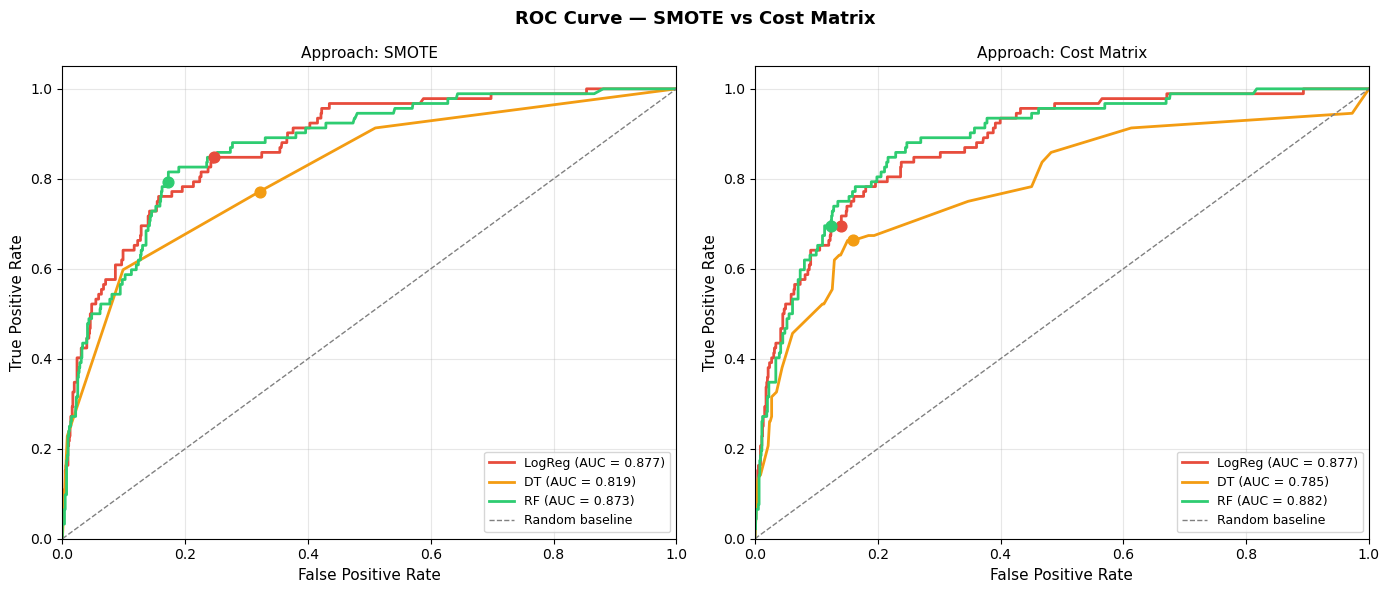

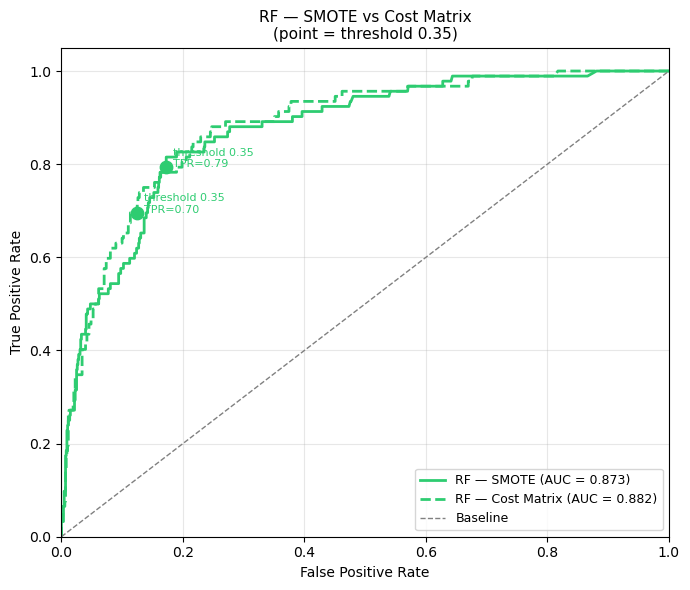

In [24]:
# =========================================================
# ROC CURVE — FULL MODEL COMPARISON (SMOTE vs COST MATRIX)
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("ROC Curve — SMOTE vs Cost Matrix",
             fontsize=13, fontweight='bold')

# ── palette ──────────────────────────────────────────────
palette = {
    'LogReg': '#e74c3c',
    'DT': '#f39c12',
    'RF': '#2ecc71',
}

# ── SMOTE models (already trained) ───────────────────────
smote_models = {
    'LogReg': log_reg,
    'DT': dt_best_model,
    'RF': rf_best_model,
}

# ── Cost Matrix models (already trained) ────────────────
cost_models = {
    'LogReg': log_cost,
    'DT': dt_cost,
    'RF': rf_cost,
}

for ax, (models_dict, title) in zip(axes, [
    (smote_models, 'SMOTE'),
    (cost_models, 'Cost Matrix'),
]):
    for name, model in models_dict.items():

        y_prob = model.predict_proba(X_test_13)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        ax.plot(
            fpr, tpr,
            linewidth=2,
            color=palette[name],
            label=f'{name} (AUC = {roc_auc:.3f})'
        )

        # threshold point at 0.35 on ROC curve
        _, _, roc_thresh = roc_curve(y_test, y_prob)
        thresh_idx = np.argmin(np.abs(roc_thresh - THRESHOLD))

        ax.scatter(
            fpr[thresh_idx],
            tpr[thresh_idx],
            color=palette[name],
            s=60,
            zorder=5
        )

    ax.plot([0, 1], [0, 1], '--', linewidth=1,
            color='grey', label='Random baseline')

    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate", fontsize=11)
    ax.set_title(f"Approach: {title}", fontsize=11)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ── Single comparative ROC: RF SMOTE vs RF Cost Matrix ───
# (cleanest pitch view — same model, two training strategies)

fig, ax = plt.subplots(figsize=(7, 6))

for label, model, ls in [
    ('RF — SMOTE', rf_best_model, '-'),
    ('RF — Cost Matrix', rf_cost, '--'),
]:
    y_prob = model.predict_proba(X_test_13)[:, 1]
    fpr, tpr, roc_thresh = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    ax.plot(
        fpr, tpr,
        linestyle=ls,
        linewidth=2,
        color='#2ecc71',
        label=f'{label} (AUC = {roc_auc:.3f})'
    )

    thresh_idx = np.argmin(np.abs(roc_thresh - THRESHOLD))

    ax.scatter(
        fpr[thresh_idx],
        tpr[thresh_idx],
        color='#2ecc71',
        s=80,
        zorder=5
    )

    ax.annotate(
        f"  threshold {THRESHOLD}\n  TPR={tpr[thresh_idx]:.2f}",
        xy=(fpr[thresh_idx], tpr[thresh_idx]),
        fontsize=8,
        color='#2ecc71'
    )

ax.plot([0, 1], [0, 1], '--', linewidth=1,
        color='grey', label='Baseline')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("RF — SMOTE vs Cost Matrix\n(point = threshold 0.35)", fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()